# SkillSwap Data Analysis

## 1. Load Data
## 2. Clean Data
## 3. Skill Demand vs Supply
## 4. Insights


In [ ]:
import pandas as pd

users = pd.read_csv("users.csv")
requests = pd.read_csv("requests.csv")
feedback = pd.read_csv("feedback.csv")

users

,user_id,skills_offered,skills_requested
0,1,Python,Web Design
1,2,HTML CSS,Python
2,3,Java Android,UI Design
3,4,UI Design,Java


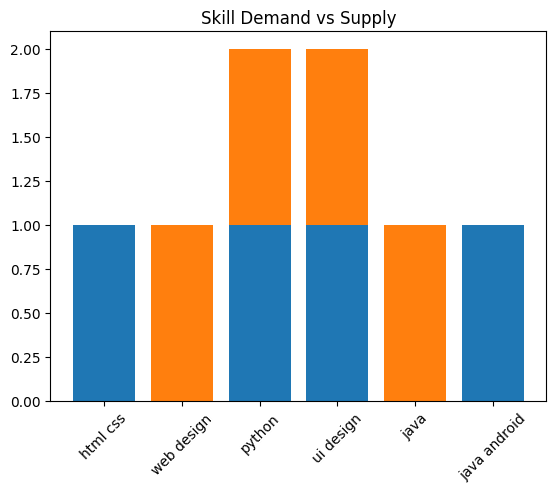

In [ ]:
import matplotlib.pyplot as plt

skills = list(set(list(offered.keys()) + list(requested.keys())))
offered_counts = [offered.get(skill, 0) for skill in skills]
requested_counts = [requested.get(skill, 0) for skill in skills]

plt.figure()
plt.bar(skills, offered_counts)
plt.bar(skills, requested_counts, bottom=offered_counts)
plt.xticks(rotation=45)
plt.title("Skill Demand vs Supply")
plt.show()

In [ ]:
users['skills_offered'] = users['skills_offered'].str.lower()
users['skills_requested'] = users['skills_requested'].str.lower()

In [ ]:
users['skills_offered'] = users['skills_offered'].str.split(',')
users['skills_requested'] = users['skills_requested'].str.split(',')

In [ ]:
from collections import Counter

offered = Counter()
requested = Counter()

for skills in users['skills_offered']:
    offered.update([s.strip() for s in skills])

for skills in users['skills_requested']:
    requested.update([s.strip() for s in skills])

offered, requested

(Counter({'python': 1, 'html css': 1, 'java android': 1, 'ui design': 1}),
 Counter({'web design': 1, 'python': 1, 'ui design': 1, 'java': 1}))

In [ ]:
skill_gap = {}

for skill in skills:
    skill_gap[skill] = requested.get(skill, 0) - offered.get(skill, 0)

skill_gap

{'html css': -1,
 'web design': 1,
 'python': 0,
 'ui design': 0,
 'java': 1,
 'java android': -1}

### Skill Gap Analysis
Positive values indicate skills with higher demand than supply.
This insight helps the platform prioritize skill recommendations.


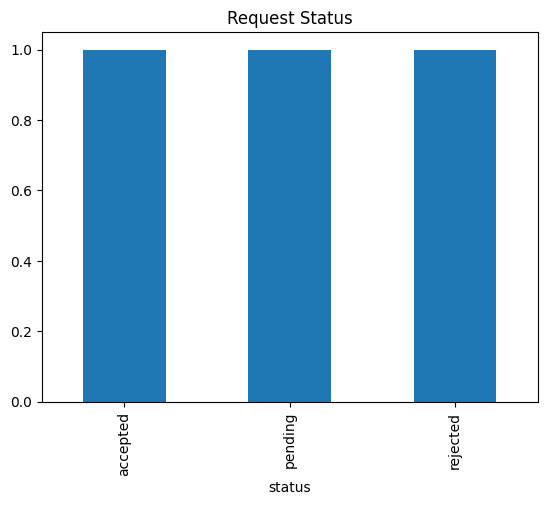

In [ ]:
requests['status'].value_counts().plot(kind='bar', title='Request Status')
plt.show()

## Key Insights

1. Python-related skills show higher demand compared to supply.
2. UI and design skills have better matching success.
3. Many requests remain pending, indicating the need for improved matching logic.


In [ ]:
#AI Skill Matching
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

skill_text = users['skills_offered'].apply(lambda x: ' '.join(x))
tfidf = TfidfVectorizer()
matrix = tfidf.fit_transform(skill_text)
similarity = cosine_similarity(matrix)

similarity

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

## AI-Based Skill Matching

TF-IDF and cosine similarity were used to measure similarity between users' offered skills.
This logic can improve recommendation accuracy in future versions of SkillSwap.


## Conclusion
This analysis helps identify high-demand skills, supply gaps, and
improves peer-to-peer skill matching on the SkillSwap platform.
